# 02 - Bias and Fairness Analysis

**NovaCred Credit Application Governance Analysis**

This notebook documents the bias and fairness assessment of the cleaned credit
applications dataset. We systematically evaluate potential disparities in loan
approval outcomes across protected and related attributes, focusing on
**gender bias**, **age-based discrimination**, and **proxy discrimination**.

The analysis includes the computation of **fairness metrics** (such as the
Disparate Impact Ratio), **statistical significance testing**, and exploratory
analysis of **interaction effects** between demographic attributes.
The goal is to identify whether the credit approval process exhibits patterns
that may indicate unfair or discriminatory outcomes.

## 1. Imports & Load Data 

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy import stats
from dateutil import parser as date_parser


df = pd.read_csv("../data/cleaned_credit_applications.csv")
df.shape, df.columns.tolist()

((500, 29),
 ['app_id',
  'full_name',
  'email',
  'ssn',
  'ip_address',
  'gender',
  'date_of_birth',
  'zip_code',
  'annual_income',
  'credit_history_months',
  'debt_to_income',
  'savings_balance',
  'spending_total',
  'spending_categories',
  'spending_category_list',
  'loan_approved',
  'interest_rate',
  'approved_amount',
  'rejection_reason',
  'processing_timestamp',
  'loan_purpose',
  'notes',
  'gender_original',
  'date_of_birth_original',
  'high_dti_flag',
  'email_valid',
  'completeness_score',
  'completeness_pct',
  'ssn_duplicate_flag'])

## 2. Outcome And Age Variable Calculation

In this section, we prepare key variables required for the bias and fairness analysis. 
Specifically, we construct the binary **loan approval outcome** used throughout the analysis 
and derive an **age variable** from the applicants' date of birth. 

To facilitate fairness assessments, applicants are additionally grouped into **age categories**, 
allowing us to evaluate potential disparities in loan approval outcomes across demographic groups. 
These variables serve as the basis for subsequent fairness metrics, statistical testing, 
and bias analysis.

### 2.1 Define Loan Approval Outcome

In [25]:
# Outcome
df["loan_approved"] = df["loan_approved"].astype(bool)

### 2.2 Compute Applicant Age

In [27]:
# Age from date_of_birth (cleaning notebook already parsed dates at some point, but CSV may store as string)
df["date_of_birth"] = pd.to_datetime(df["date_of_birth"], errors="coerce")

today = pd.Timestamp("today").normalize()
df["age"] = ((today - df["date_of_birth"]).dt.days / 365.25).round(1)

### 2.3 Create Age Groups

In [29]:
# Age groups (feel free to tweak bins after you look at distribution)
bins = [0, 29, 44, 59, 120]
labels = ["<30", "30–44", "45–59", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

### 2.4 Age Distribution Histogram

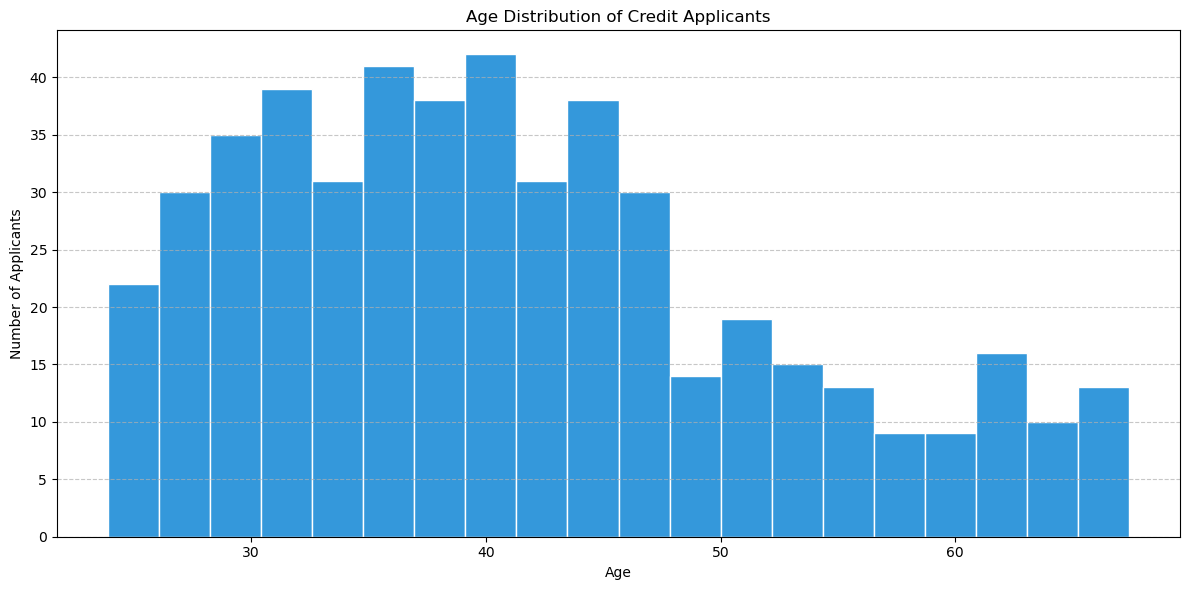

In [23]:
# Age distribution visualization (consistent style with Data Quality notebook)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_main["age"], bins=20, color="#3498db", edgecolor="white")

ax.set_title("Age Distribution of Credit Applicants")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Applicants")

# add gridlines like in the data quality notebook
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 3. Main Cohort Definition

This section defines the primary analysis cohort, which is used to analyze fairness and bias.
To guarantee methodological consistency, we restrict the dataset to applicants with a valid binary gender classification (**Male/Female**) for the baseline Disparate Impact analysis, ensuring non-missing data.**Age** values are for age-based and intersectional analysis.

To ensure transparency and reproducibility, we document cohort size and group numbers after filtering.

In [32]:
# Define main cohort used for the bias analysis

total_records = len(df)

# keep only applicants with binary gender (Male / Female)
gender_filter = df["gender"].isin(["Male", "Female"])
records_after_gender_filter = gender_filter.sum()

# ensure age is available for age-related analysis
age_filter = df["age"].notna()
records_after_age_filter = (gender_filter & age_filter).sum()

# create main analysis dataset
df_main = df[gender_filter & age_filter].copy()

# summary of filtering steps
cohort_summary = pd.DataFrame({
    "Step": ["Total records","After gender filter","After gender + age filter (df_main)"],
    "Records": [total_records,int(records_after_gender_filter),int(records_after_age_filter)],
    "Dropped": [0,int(total_records - records_after_gender_filter),int(records_after_gender_filter - records_after_age_filter)]
})

cohort_summary

,Step,Records,Dropped
0,Total records,500,0
1,After gender filter,498,2
2,After gender + age filter (df_main),495,3


## 4. Gender Bias: Disparate Impact + Statistical Test

Here, we examine whether the **loan approval rate** differs between gender groups.
To do this, we do two things:

1) **Disparate Impact (DI) Ratio**: Approval Rate (Female) / Approval Rate (Male) and classification according to the **Four-Fifths Rule (0.8)**
2) **Significance test**: Chi-square test on the 2×2 crosstab (gender × approval), plus **Cramér's V** as effect size

Important: These are **associations**, not causal statements.

### 4.1 Approval rates by gender

In [34]:
approval_by_gender = df_main.groupby("gender")["loan_approved"].mean().sort_index()
counts_by_gender = df_main["gender"].value_counts().sort_index()

approval_by_gender, counts_by_gender

(gender
 Female    0.506024
 Male      0.658537
 Name: loan_approved, dtype: float64,
 gender
 Female    249
 Male      246
 Name: count, dtype: int64)

### 4.2 Disparate Impact

In [35]:
privileged = "Male"
protected = "Female"

di_gender = approval_by_gender[protected] / approval_by_gender[privileged]
di_gender

np.float64(0.7684069611780454)

### 4.3 Four-fifths rule as an interpretation helper

In [36]:
def four_fifths_interpretation(di_value: float, threshold: float = 0.8) -> str:
    if di_value < threshold:
        return f"DI={di_value:.3f} < {threshold}: potential adverse impact under the four-fifths rule."
    return f"DI={di_value:.3f} ≥ {threshold}: no adverse impact flagged by the four-fifths rule."

four_fifths_interpretation(di_gender)

'DI=0.768 < 0.8: potential adverse impact under the four-fifths rule.'

### 4.4 Chi-square test (Gender x Approval) + Cramér's V

In [37]:
ct_gender = pd.crosstab(df_main["gender"], df_main["loan_approved"])
ct_gender

loan_approved,False,True
gender,,
Female,123,126
Male,84,162


In [38]:
chi2, p, dof, expected = stats.chi2_contingency(ct_gender)

# Cramér's V (effect size)
n = ct_gender.to_numpy().sum()
r, k = ct_gender.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, k-1)))

chi2, p, cramers_v

(np.float64(11.211547625416834),
 np.float64(0.0008128989785515719),
 np.float64(0.15049781115504057))

#### The bar chart below visualizes the approval rate difference between the two gender groups:

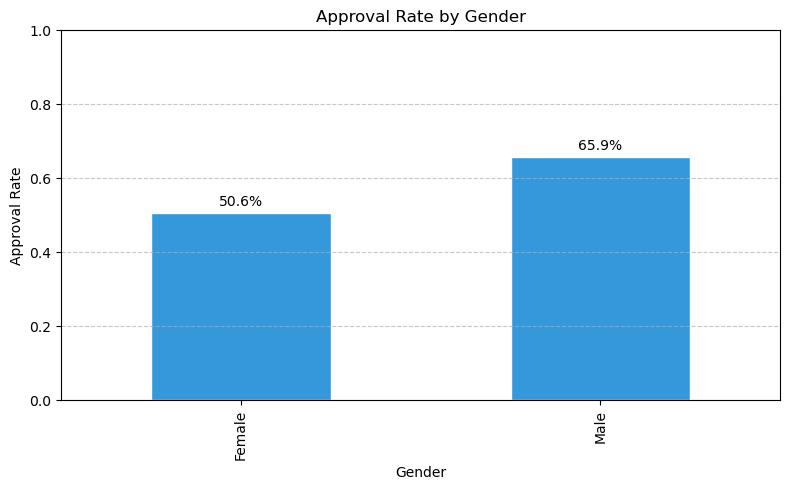

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
approval_by_gender.plot(kind="bar", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Approval Rate by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.7)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:.1%}" for v in approval_by_gender], padding=3)
plt.tight_layout()
plt.show()

#### Interpretation:

The acceptance rate varies significantly between gender groups. Female candidates had an approval rate of **50.6%**, whilst male applicants are approved in **65.9%** of situations.

The resulting **Disparate Impact (DI) ratio is 0.768**, which is **less than the Four-Fifths Rule threshold of 0.8.** According to this rule, the outcome **indicates a potential negative impact on female applicants.**

The **Chi-Square test** produces a p-value of 0.0008, suggesting that the observed difference in approval rates between genders is **statistically significant** and is unlikely to be explained by random fluctuation.

However, the **Cramér's V value of 0.15 indicates a modest association** between gender and loan approval. This means that, while the difference is statistically important, the relationship's overall strength is **moderate to small**.

Overall, the analysis demonstrates **a detectable gender gap in approval outcomes**, however the impact size implies that gender alone accounts for only a portion of the variation in loan choices. Importantly, these findings indicate statistical relationships rather than causal discrimination.